# DQN with MountainCar-v0 Environment

This notebook loads [config.yaml](configs/config.yaml) and trains the `QAgent` on `MountainCar-v0` using the Gymnassium API for envrionment.

MountainCar has a `Box(2,)` **observation space** (position, velocity) and a `Discrete(3)` **action space** (push left, no push, push right). The reward is a constant `-1` per step until the car reaches the flag (200-step limit), so the exploration problem is hard: there is no learning signal until epsilon-greedy stumbles on the goal. The recipe here is the Acrobot one (mid-episode training every 2 steps, Polyak target updates), which shares the constant `-1`/step reward structure.

## Imports

In [1]:
import sys, pathlib, yaml
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SRC = pathlib.Path.cwd().parents[2] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from environments.base_env import make_environment
from agents.q_agent import QAgent
from utils.device import resolve_device
from training import dqn_training_loop
from experiment import make_run_logger
from analysis.registry import resolve_methods
from analysis.low_rank.rank import plot_matrix_spectra, row_rank_property_check
from analysis.visualisations.heatmaps import plot_matrix_heatmap

## Reading the `config` file

In [2]:
# Reading the experiment config file
with open("configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

# Gathering torch backend and experiment seed
dev = cfg["experiment"]["device"]
device = resolve_device(dev)
seed = cfg["experiment"]["seed"]
torch.manual_seed(seed)
np.random.seed(seed)

cfg

{'experiment': {'name': 'dqn_mountaincar',
  'seed': 52,
  'device': 'auto',
  'save_artifacts': True},
 'environment': {'name': 'MountainCar-v0',
  'render_mode': None,
  'discrete_config': None,
  'normalise': {'action': {}, 'state': {'min': [-1, -1], 'max': [1, 1]}},
  'clip': {'action': False, 'state': []}},
 'network': {'hidden_sizes': [64, 64]},
 'agent': {'replay_buffer_capacity': 100000,
  'batch_size': 128,
  'nn_learning_rate': 0.0005,
  'eps_start': 1.0,
  'eps_min': 0.05,
  'decay_rate': 0.99997,
  'discount_factor': 0.99,
  'TD_LR': 0.005,
  'buffer_util': 1,
  'gd_steps_ceil': 1,
  'grad_clip_norm': 20.0,
  'double': True},
 'training': {'no_episodes': 2000,
  'target_network_update_steps': 2,
  'train_frequency_steps': 2,
  'use_episode_training': False,
  'solved_reward': -110,
  'warmup_steps': 10000,
  'early_stopping_patience_eps': 50,
  'no_eps_to_avg': 25},
 'analysis': {'ep_freq': 50,
  'methods': [{'name': 'q_matrix_dqn',
    'kwargs': {'state_discretisation': [3

## Creating the Envrionment

In [3]:
env_cfg = cfg["environment"]
env = make_environment(
    env_cfg["name"],
    render_mode=env_cfg["render_mode"],
    discrete_config=env_cfg["discrete_config"],   # None -> no discretisation
    normalise=env_cfg["normalise"],               # position/velocity rescaled to [-1, 1]
    clip=env_cfg["clip"],
)
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n
print("obs_dim:", obs_dim, "n_actions:", n_actions)

obs_dim: 2 n_actions: 3


## Creating the Agent

In [4]:
class QNetwork(nn.Module):
    """Maps a state (obs_dim,) -> Q-values (n_actions,). Built by QAgent via q_network(**nn_extra_kwargs)."""
    def __init__(self, in_dim, out_dim, hidden_sizes=(64, 64)):
        super().__init__()
        layers, last = [], in_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        layers.append(nn.Linear(last, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [5]:

a = cfg["agent"]
nn_extra_kwargs = {
    "in_dim": obs_dim,
    "out_dim": n_actions,
    "hidden_sizes": cfg["network"]["hidden_sizes"],
}
agent = QAgent(
    replay_buffer_capacity=a["replay_buffer_capacity"],
    q_network=QNetwork,
    batch_size=a["batch_size"],
    nn_learning_rate=a["nn_learning_rate"],
    nn_extra_kwargs=nn_extra_kwargs,
    env=env,
    eps_start=a["eps_start"],
    eps_min=a["eps_min"],
    decay_rate=a["decay_rate"],
    discount_factor=a["discount_factor"],
    device=device,
    TD_LR=a["TD_LR"],
    buffer_util=a["buffer_util"],
    gd_steps_ceil=a["gd_steps_ceil"],
    grad_clip_norm=a["grad_clip_norm"],
    double=a["double"]
)

## Analysis (Low Rank)

In [6]:
analysis = cfg["analysis"]

# Methods resolve from the raw config inside the training loop (analysis.registry),
# and Hankel runs via the analysis.hankel_sweep block dispatched there every ep_freq
# episodes — no manual method wiring in the notebook.
analysis

{'ep_freq': 50,
 'methods': [{'name': 'q_matrix_dqn',
   'kwargs': {'state_discretisation': [32, 32], 'batch_size': 64},
   'outputs': ['Q-function']}],
 'hankel_sweep': {'enabled': True,
  'n_rollouts': 10,
  'base_seed': 52,
  'functions': ['Hankel Q', 'Hankel V'],
  'save_trajectories': True,
  'sub_trajectory': {'enabled': False,
   'min_len': 20,
   'stride': 20,
   'n_figures': 5}}}

## Agent Training 

In [7]:
t = cfg["training"]
run_logger = make_run_logger(cfg, config_path="configs/config.yaml", base_dir="cached")  # cached/runs/<experiment.name>_<timestamp>/ artifacts when experiment.save_artifacts, else figures render inline
rewards = dqn_training_loop(
    agent, env,
    no_episodes=t["no_episodes"],
    target_network_update_steps=t["target_network_update_steps"],
    train_frequency_steps=t["train_frequency_steps"],
    use_episode_training=t["use_episode_training"],
    solved_reward=t["solved_reward"],
    warmup_steps=t["warmup_steps"],
    early_stopping_patience_eps=t["early_stopping_patience_eps"],
    no_eps_to_avg=t["no_eps_to_avg"],
    np_seed=seed,
    analysis_config=analysis,
    DEBUG=False,
    run_logger=run_logger,
)

  0%|          | 0/2000 [00:00<?, ?it/s]

episode 0 avg_rewarg: -200.0


****************************Q-function****************************
eff_rank: 1, stable_rank: 1.05, spikiness: 1.65, shape: (1024, 3), non-zero rows :1024, non-zero cols:3
top-r leverage spread: row min=0.0003458 max=0.001539 (uniform 0.0009766) | col min=0.05411 max=0.6676 (uniform 0.3333)
coherence score: row=1.576 col=2.003


  0%|          | 1/2000 [00:02<1:09:07,  2.07s/it]

  1%|          | 11/2000 [00:02<04:50,  6.86it/s] 

...

 35%|███▌      | 709/2000 [03:00<02:57,  7.27it/s]

 36%|███▌      | 710/2000 [03:00<02:52,  7.46it/s]

 36%|███▌      | 711/2000 [03:00<02:47,  7.70it/s]

 36%|███▌      | 711/2000 [03:00<05:27,  3.94it/s]

Average trajectory (episode total) reward for 50 episodes is -109.44
Triggering Early Stopping !!
run artifacts saved under /home/souparna/Low-Rank-RL-TL/experiments/dqn_mountaincar/runs/dqn_mountaincar_20260811-160459


## Training and Analysis Plots (now with pi*(theeta))

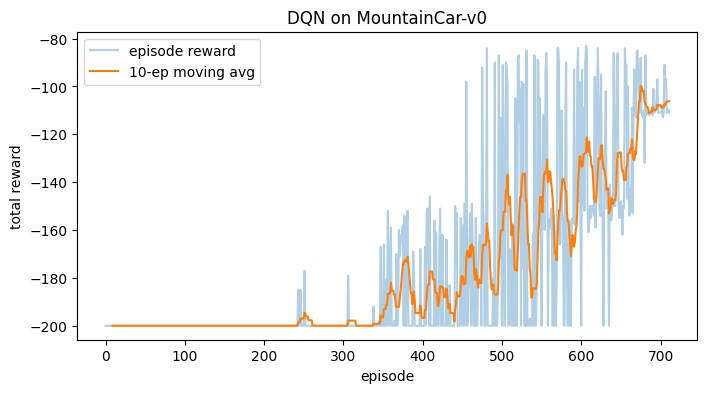

In [8]:
rewards = np.asarray(rewards, dtype=float)
plt.figure(figsize=(8, 4))
plt.plot(rewards, alpha=0.35, label="episode reward")
if len(rewards) >= 10:
    k = 10
    ma = np.convolve(rewards, np.ones(k) / k, mode="valid")
    plt.plot(range(k - 1, len(rewards)), ma, label=f"{k}-ep moving avg")
plt.xlabel("episode"); plt.ylabel("total reward"); plt.title("DQN on MountainCar-v0")
plt.legend(); plt.show()

Q-function


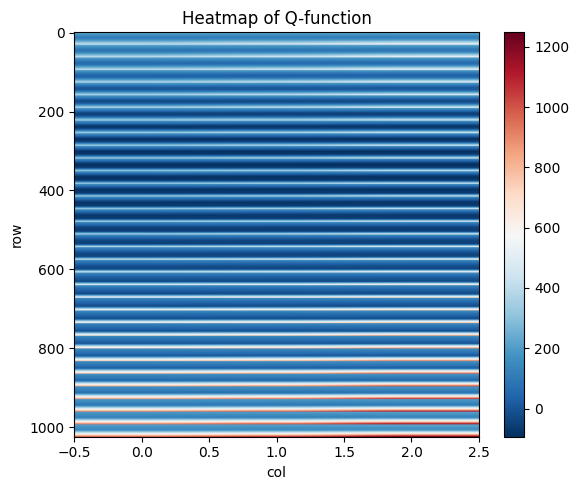

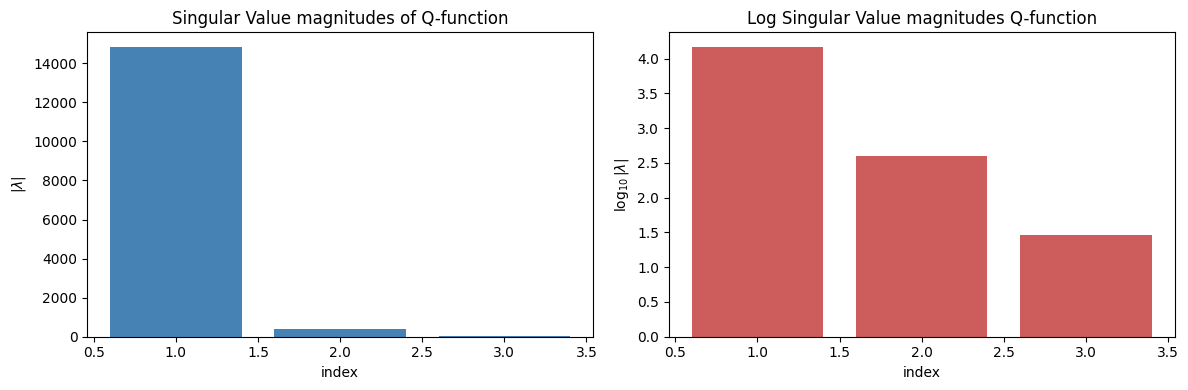

eff_rank: 1, stable_rank: 1.00, spikiness: 4.66, shape: (1024, 3), non-zero rows :1024, non-zero cols:3
top-r leverage spread: row min=1.501e-09 max=0.01704 (uniform 0.0009766) | col min=0.272 max=0.412 (uniform 0.3333)
coherence score: row=17.45 col=1.236


In [9]:
for method, names in resolve_methods((analysis.get("methods") or []) + (analysis.get("post_methods") or [])):
    results = method(agent=agent, env=env)
    if not isinstance(results, tuple):
        results = (results,)
    for matrix, name in zip(results, names):
        print(name)
        plot_matrix_heatmap(matrix, name)
        r, sr, spk, shape, irs, ics, rc, cc, nzr, nzc = row_rank_property_check(matrix, name)
        print(f"eff_rank: {r}, stable_rank: {sr:.2f}, spikiness: {spk:.2f}, shape: {shape}, non-zero rows :{nzr}, non-zero cols:{nzc}")
        print(f"top-r leverage spread: row min={irs.min():.4g} max={irs.max():.4g} (uniform {1.0/shape[0]:.4g}) | col min={ics.min():.4g} max={ics.max():.4g} (uniform {1.0/shape[1]:.4g})")
        print(f"coherence score: row={rc:.4g} col={cc:.4g}")

## Greedy rollout video

Record one greedy (`act_greedy`) episode of the trained `agent` and display it inline. The eval env is rebuilt with `render_mode="rgb_array"` so frames can be captured.

In [10]:
# Greedy rollout video of the trained agent
from analysis.visualisations.rollout_video import record_greedy_episode
from IPython.display import Video
import glob

video_dir = "videos"
eval_env = make_environment(
    env_cfg["name"],
    render_mode="rgb_array",
    discrete_config=env_cfg["discrete_config"],
    normalise=env_cfg["normalise"],
    clip=env_cfg["clip"],
)
prefix = record_greedy_episode(agent, eval_env, video_dir, episode=0, seed=seed)
mp4 = sorted(glob.glob(f"{video_dir}/{prefix}-*.mp4"))[-1]
print("saved:", mp4)
Video(mp4, embed=True)

saved: videos/ep0-episode-0.mp4
